# TEIS BDI-3 Analysis

[The Tennessee Early Intervention System (TEIS)](https://www.tn.gov/didd/for-consumers/tennessee-early-intervention-system-teis.html) is a voluntary program that offers therapy and other services to families of infants and young children with developmental delays or disabilities. Services are provided at no cost to families. TEIS is critically important to supporting the development of Tennessee children with disabilities and developmental delays as they prepare for school.

In this project, you are going to be working with data gathered from the Battelle Developmental Inventory, Third Edition (BDI-3) Eligibility Evaluation, an early childhood instrument based on the concept of developmental milestones. The BDI-3 is used by TEIS for determining eligibility and outcomes. This assessment tool has been in use for less than a year now, so the purpose of your work is to analyze the scores to see if there appear to be any weaknesses in this tool in any of the assessed domains or subdomains.

The BDI-3 is divided into 5 domains, each of which has 2 or 3 subdomains. On each domain and subdomain, a child receives several different scores. An example score report is available in the BDI3_ScoreReport.pdf file. See page 3 of this file for a detailed description of each score. Note that the BDI-3 is norm-based, meaning that the scores are generated by the child's performance based on the performance of same-aged peers on the same items. 

---------------------------------------------------------------------------------------------------------------------------------------------

# Some notes about the data:
* The same instrument is used for determining eligibility and outcomes. The type of evaluation can be determined from the "Program Label" column, which will indicate either an eligibility evaluation, an annual evaluation, or a birthday/milestone or exit evaluation. 
* Some of the rows are duplicated, so be sure to check that in your initial data inspection and cleaning. In addition, some children will have multiple rows in the dataset. A child is evaluated at initial eligibility, annually, and at their 3rd birthday or exit under certain circumstances. The evaluation may be repeated every 4 months (e.g. a child was ineligible and re-referred). 
* There are many records that are missing ID numbers. These records have been given a unique identifier which starts with "SP" so that they can be identified.
* When reading the data in, you may notice that some of the values in the RDI columns are incorrectly converted to dates. It is likely that this happens whenever the numerator of the fraction is 12 or less.


---------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
import pandas as pd
import re

In [7]:
df = pd.read_csv(r'C:\Users\chloe\Documents\NSS\Python\data\CBDI3_evals.csv', encoding='cp1252',  low_memory=False)
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### deleting the last 10, empty columns

In [8]:
df = df.iloc[:, :-10]
df.copy()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98/90,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29/90,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37/90,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92/90,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,6.0,15.0,95,6,>99/90,378.0,365 - 391,1.67,67.0,85
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,20.0,14.0,91,37,99/90,499.0,491 - 508,1.33,63.0,78
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,13.0,10.0,50,25,89/90,464.0,450 - 479,0,50.0,50
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,23.0,9.0,37,40,75/90,507.0,500 - 515,– 0.33,47.0,43


#### cleaning the rdi columns

In [9]:
df.columns = [col + ' (out of 90)' if col in rdi_cols else col for col in df.columns]
df

NameError: name 'rdi_cols' is not defined

In [ ]:
rdi_cols = df.columns[df.columns.str.endswith('RDI')]

for col in rdi_cols:
    df[col] = df[col].astype(str).str.replace('/90', '', regex=False)

df

In [ ]:
month_prefixes = ('Jan-', 'Feb-', 'Mar-', 'Apr-', 'May-', 'Jun-',
                   'Jul-', 'Aug-', 'Sep-', 'Oct-', 'Nov-', 'Dec-')

def strip_month(val):
    val = str(val)
    if val.startswith(month_prefixes):
        return val[4:]
    return val

for col in rdi_cols:
    df[col] = df[col].apply(strip_month)

In [65]:
df

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
0,44879,F,9/27/2022,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,9.0,13.0,84,12,98/90,411.0,392 - 431,1,60.0,71
1,47795,F,12/23/2020,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,11.0,7.0,16,18,29/90,437.0,421 - 453,– 1.00,40.0,29
2,54340,M,6/22/2021,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,10.0,7.0,16,15,37/90,426.0,408 - 444,– 1.00,40.0,29
3,54344,F,3/7/2022,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,9.0,10.0,50,12,92/90,411.0,392 - 431,0,50.0,50
4,54515,M,11/4/2021,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,10.0,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,9/25/2023,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,6.0,15.0,95,6,>99/90,378.0,365 - 391,1.67,67.0,85
23943,SP03288,F,5/18/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,25.0,115.0,84,107-121,...,20.0,14.0,91,37,99/90,499.0,491 - 508,1.33,63.0,78
23944,SP03289,F,10/31/2021,South Central,contract 2,BDI-3 Eligibility Evaluation,21.0,103.0,58,96-110,...,13.0,10.0,50,25,89/90,464.0,450 - 479,0,50.0,50
23945,SP03290,M,3/25/2020,Memphis Delta,contract 3,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,23.0,9.0,37,40,75/90,507.0,500 - 515,– 0.33,47.0,43


# Score Descriptors

### SS
Standard Score or Scale Score - Domain Standard Scores (SS), also called Developmental Quotients
(DQ), have a mean of 100 and standard deviation of 15. A Domain SS of 85 falls at the 16th percentile, 100 at the
50th, and a SS of 115 falls at the 84th percentile. Subdomain scaled scores have a mean of 10 and standard
deviation of 3. A scaled score of 7 falls at the 16th percentile, a scaled score of 10 falls at the 50th, and a scaled
score of 13 falls at the 84th percentile.
### PR
Percentile Rank scores reflect a child’s relative position within the normative sample for his or her age
group.
### Z-Score
A Z-Score is a score that is measured in terms of standard deviations from the average, or mean, and is
expressed as 0, positive numbers, or negative numbers. A Z-score of 0 falls at the mean.
### AE
Age Equivalent indicates the age at which a specific raw score is equal to the median (50th percentile)
obtained by children of a given age.
### CSS 
Change Sensitive Score the CSS represents a discrete point on the developmental milestone continuum
underlying each subdomain. The CSS scale is centered so that a score of 500 on each subdomain represents the
developmental level of a typical 36-month-old child and is best used to compare two administrations of the BDI-3
in order to assess change over time.
### RDI
The Relative Developmental Index (RDI) is expressed as a fraction, with the bottom number as 90, or 90%
proficiency for the examinee’s age group. The numerator is a number ranging from 0 to 100 and expresses the
examinee’s proficiency.
### T-Score
A T-Score is a score that has a mean of 50 and a standard deviation of 10.
### NCE
The Normal Curve Equivalent is another commonly reported type of standard score that has a mean of 50
and a standard deviation of 21.06.

# Project Objectives

# 1. In which domains (and sub-domains) are children performing highest and lowest?

In [11]:
dq = df[df.columns[df.columns.str.endswith('Developmental Quotient')]]

dq.astype('int32', errors='ignore')


,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient,BDI-3 Total Developmental Quotient
0,85.0,127.0,91.0,88.0,100.0,99.0
1,88.0,104.0,97.0,102.0,100.0,99.0
2,90.0,91.0,82.0,109.0,83.0,89.0
3,115.0,103.0,88.0,91.0,113.0,101.0
4,75.0,73.0,70.0,73.0,97.0,71.0
...,...,...,...,...,...,...
23942,115.0,115.0,112.0,118.0,113.0,119.0
23943,115.0,116.0,112.0,117.0,122.0,119.0
23944,103.0,102.0,55.0,104.0,98.0,94.0
23945,88.0,90.0,76.0,100.0,88.0,88.0


### Isolating the developmental quotient columns

In [12]:
dq.describe()

,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient,BDI-3 Total Developmental Quotient
count,23939.000000,23927.000000,23912.000000,23912.000000,23926.000000,23880.000000
mean,86.988304,94.293601,79.060723,93.875711,88.412188,87.216332
std,17.689509,16.819322,20.417259,17.731262,16.620340,17.178270
min,46.000000,46.000000,46.000000,42.000000,40.000000,40.000000
25%,76.000000,84.000000,64.000000,83.000000,78.000000,76.000000
50%,88.000000,94.000000,79.000000,96.000000,90.000000,88.000000
75%,100.000000,106.000000,94.000000,106.000000,100.000000,99.000000
max,148.000000,154.000000,154.000000,154.000000,160.000000,160.000000


### Domain Performance
Children are performing highest in Social-Emotional and Motor catagories, with an average close to the 100 mark. They also have slightly lower stanard deviations, representing a less spread out range of scores 

On the other hand, children asssesed for the Communication catagory score lower on average, at 79. In addition, a std score of 20.4 represents a more spread out, wide range of scores across all children assessed.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

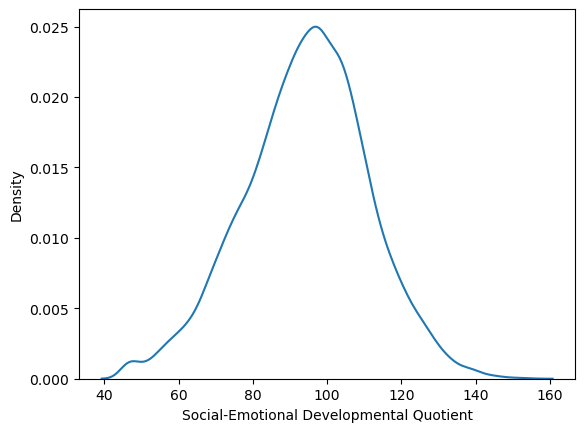

In [14]:
SE_plot = sns.kdeplot(data=dq, x='Social-Emotional Developmental Quotient')
SE_plot.figure.savefig('my_plot1.jpg') 

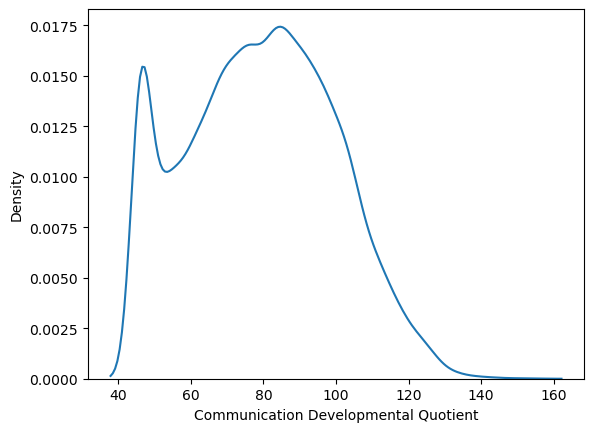

In [16]:
communication_plot = sns.kdeplot(data=dq, x='Communication Developmental Quotient')
communication_plot
communication_plot.figure.savefig('my_plot2.jpg') 

 ### to look at subdomains, we use the Scaled Score (SS). a score of 10 repesents a typical score for the student based on their age. 

In [36]:
sd= df[df.columns[df.columns.str.endswith(' SS')]]

sd

,Adaptive-Self Care SS,Adaptive-Personal Responsibility SS,Social Emotional-Adult Interaction SS,Social Emotional-Peer Interaction SS,Social Emotional-Self Concept / Social Role SS,Communication-Receptive Communication SS,Communication-Expressive Communication SS,Motor-Gross Motor SS,Motor-Fine Motor SS,Motor-Perceptual Motor SS,Cognitive-Attention and Memory SS,Cognitive-Reasoning / Academic Skills SS,Cognitive-Perception and Concepts SS
0,7.0,NaN,14.0,NaN,15.0,8.0,9.0,7.0,9.0,NaN,7.0,NaN,13.0
1,7.0,9.0,12.0,9.0,11.0,10.0,9.0,7.0,13.0,11.0,9.0,14.0,7.0
2,8.0,NaN,11.0,NaN,6.0,7.0,7.0,11.0,12.0,NaN,8.0,NaN,7.0
3,13.0,NaN,10.0,NaN,11.0,8.0,8.0,5.0,12.0,NaN,14.0,NaN,10.0
4,5.0,NaN,6.0,NaN,5.0,5.0,5.0,3.0,8.0,NaN,9.0,NaN,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,13.0,NaN,13.0,NaN,12.0,12.0,12.0,11.0,15.0,NaN,9.0,NaN,15.0
23943,10.0,15.0,12.0,13.0,13.0,14.0,10.0,15.0,11.0,12.0,13.0,14.0,14.0
23944,10.0,11.0,12.0,10.0,9.0,4.0,1.0,11.0,10.0,11.0,10.0,9.0,10.0
23945,6.0,10.0,8.0,11.0,6.0,7.0,5.0,9.0,10.0,11.0,7.0,8.0,9.0


In [38]:
sd= df[df.columns[df.columns.str.endswith(' SS')]]

sd_clean = sd[['Adaptive-Self Care SS', 
    'Adaptive-Personal Responsibility SS', 
    'Communication-Receptive Communication SS',
    'Communication-Expressive Communication SS',
    'Social Emotional-Adult Interaction SS',
    'Social Emotional-Peer Interaction SS',
    'Social Emotional-Self Concept / Social Role SS',
    'Motor-Fine Motor SS',
    'Motor-Perceptual Motor SS',
    'Cognitive-Attention and Memory SS',
    'Cognitive-Reasoning / Academic Skills SS',
    'Cognitive-Perception and Concepts SS']]

In [54]:
sd_clean.describe()

,Adaptive-Self Care SS,Adaptive-Personal Responsibility SS,Communication-Receptive Communication SS,Communication-Expressive Communication SS,Social Emotional-Adult Interaction SS,Social Emotional-Peer Interaction SS,Social Emotional-Self Concept / Social Role SS,Motor-Fine Motor SS,Motor-Perceptual Motor SS,Cognitive-Attention and Memory SS,Cognitive-Reasoning / Academic Skills SS,Cognitive-Perception and Concepts SS
count,23940.000000,13139.000000,23931.000000,23915.000000,23935.000000,13134.000000,23931.000000,23925.000000,13126.000000,23929.000000,13133.000000,23927.000000
mean,7.324854,8.023289,6.634700,6.386912,10.476332,7.858002,7.985584,9.670805,8.549520,8.310377,8.074317,7.619133
std,3.149402,3.931179,3.650991,3.703074,2.860787,3.330956,3.277486,3.257990,3.958829,2.729118,3.241116,3.284079
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,6.000000,5.000000,4.000000,4.000000,9.000000,5.000000,6.000000,8.000000,6.000000,7.000000,6.000000,6.000000
50%,7.000000,8.000000,7.000000,6.000000,11.000000,8.000000,8.000000,10.000000,9.000000,9.000000,8.000000,8.000000
75%,9.000000,11.000000,9.000000,9.000000,12.000000,10.000000,10.000000,12.000000,11.000000,10.000000,11.000000,10.000000
max,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000


### Highest subdomain: adult interaction (s-e)
In fact, adult interaction (sel domain) was higher on average compared to the general population.


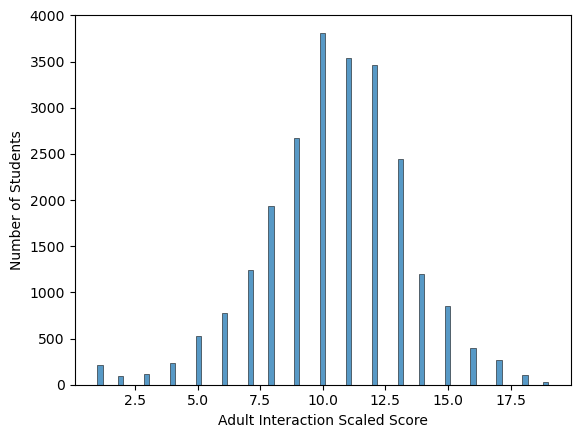

In [61]:
adult_interaction = sns.histplot(data=sd_clean, x = 'Social Emotional-Adult Interaction SS')
plt.xlabel("Adult Interaction Scaled Score")
plt.ylabel("Number of Students")
plt.show()
adult_interaction.figure.savefig('adult_interaction_plot.jpg')

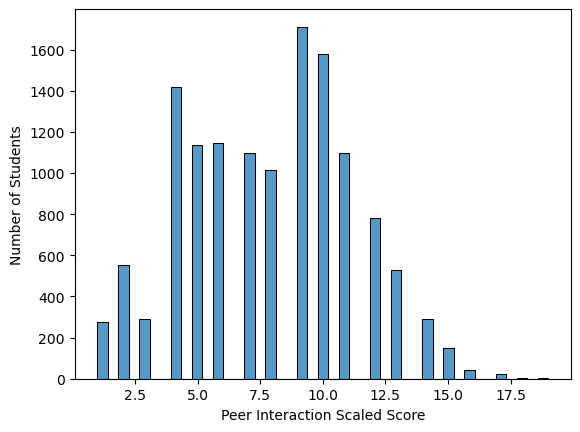

In [64]:
peer_interaction = sns.histplot(data=sd_clean, x = 'Social Emotional-Peer Interaction SS')
plt.xlabel("Peer Interaction Scaled Score")
plt.ylabel("Number of Students")
plt.show()
peer_interaction.figure.savefig('peer_interaction_plot.jpg')

### Lowest subomain: expressive communication

a std deviation of 3.7 shows there is a wide spread of scores

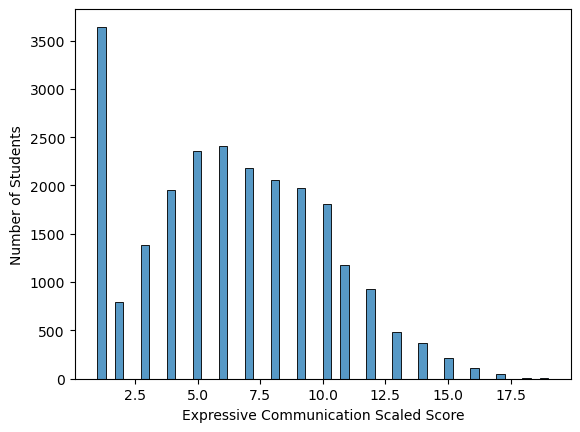

In [62]:
expressive = sns.histplot(data=sd_clean, x = 'Communication-Expressive Communication SS')
plt.ylabel("Number of Students")
plt.xlabel("Expressive Communication Scaled Score")
plt.show()
expressive.figure.savefig('expressiv_comm.jpg')

# 2. What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

# 3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain? For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility. A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language domain.

# 4. Does the child's age seem to impact their scoring?

# 5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

# 6. Is there any difference in scoring noted based on evaluation type?

eligibility evaluations typically have higher overall scores compared to annual evaluations.
Annual evaluations typically have higher stdev (more heterogeneity) 

In [97]:
adaptive_info = df.groupby('Program Label')[['Adaptive Developmental Quotient']].describe()
adaptive_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Adaptive Developmental Quotient             \
                                                             count       mean   
Program Label                                                                   
BDI-3 Eligibility Evaluation                               12397.0  89.184238   
BDI-3 Annual Evaluation                                    11203.0  84.604570   
BDI-3 Milestone or Exit Evaluation                           339.0  85.460177   

                                                                               
                                          std   min   25%   50%    75%    max  
Program Label                                                                  
BDI-3 Eligibility Evaluation        16.454346  46.0  80.0  90.0  100.0  148.0  
BDI-3 Annual Evaluation             18.617865  46.0  73.0  85.0   97.0  148.0  
BDI-3 Milestone or Exit Evaluation  19.411932  46.0  73.0  85.0  100.0  133.0

In [83]:
se_info = df.groupby('Program Label')[['Social-Emotional Developmental Quotient']].describe()

In [98]:
se_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Social-Emotional Developmental Quotient  \
                                                                     count   
Program Label                                                                
BDI-3 Eligibility Evaluation                                       12395.0   
BDI-3 Annual Evaluation                                            11193.0   
BDI-3 Milestone or Exit Evaluation                                   339.0   

                                                                            \
                                         mean        std   min   25%   50%   
Program Label                                                                
BDI-3 Eligibility Evaluation        95.432432  16.404820  46.0  85.0  97.0   
BDI-3 Annual Evaluation             93.072099  17.211439  46.0  82.0  94.0   
BDI-3 Milestone or Exit Evaluation  92.985251  15.779821  46.0  82.0  94.0   

                                                  
                                      75%    max  
Program Label                                     
BDI-3 Eligibility Evaluation        106.0  154.0  
BDI-3 Annual Evaluation             104.0  154.0  
BDI-3 Milestone or Exit Evaluation  104.0  132.0

In [85]:
comm_info = df.groupby('Program Label')[['Communication Developmental Quotient', ]].describe()

In [99]:
comm_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Communication Developmental Quotient  \
                                                                  count   
Program Label                                                             
BDI-3 Eligibility Evaluation                                    12382.0   
BDI-3 Annual Evaluation                                         11191.0   
BDI-3 Milestone or Exit Evaluation                                339.0   

                                                                            \
                                         mean        std   min   25%   50%   
Program Label                                                                
BDI-3 Eligibility Evaluation        81.181554  19.259513  46.0  67.0  82.0   
BDI-3 Annual Evaluation             76.821106  21.329070  46.0  58.0  79.0   
BDI-3 Milestone or Exit Evaluation  75.530973  22.325485  46.0  55.0  76.0   

                                                 
                                     75%    max  
Program Label                                    
BDI-3 Eligibility Evaluation        97.0  148.0  
BDI-3 Annual Evaluation             94.0  154.0  
BDI-3 Milestone or Exit Evaluation  94.0  130.0

In [92]:
motor_info = df.groupby('Program Label')[['Motor Developmental Quotient']].describe()

In [100]:
motor_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Motor Developmental Quotient             \
                                                          count       mean   
Program Label                                                                
BDI-3 Eligibility Evaluation                            12387.0  96.569629   
BDI-3 Annual Evaluation                                 11186.0  90.875648   
BDI-3 Milestone or Exit Evaluation                        339.0  94.433628   

                                                                               
                                          std   min   25%   50%    75%    max  
Program Label                                                                  
BDI-3 Eligibility Evaluation        15.749233  42.0  87.0  97.0  106.0  151.0  
BDI-3 Annual Evaluation             19.277787  42.0  79.0  94.0  104.0  154.0  
BDI-3 Milestone or Exit Evaluation  17.024630  42.0  85.0  96.0  106.0  134.0

In [94]:
cog_info = df.groupby('Program Label')[['Cognitive Developmental Quotient']].describe()

In [101]:
cog_info.reindex( index = ['BDI-3 Eligibility Evaluation', 'BDI-3 Annual Evaluation', 'BDI-3 Milestone or Exit Evaluation' ])

Cognitive Developmental Quotient  \
                                                              count   
Program Label                                                         
BDI-3 Eligibility Evaluation                                12390.0   
BDI-3 Annual Evaluation                                     11197.0   
BDI-3 Milestone or Exit Evaluation                            339.0   

                                                                            \
                                         mean        std   min   25%   50%   
Program Label                                                                
BDI-3 Eligibility Evaluation        91.002502  15.980917  40.0  80.0  92.0   
BDI-3 Annual Evaluation             85.661963  16.902346  40.0  76.0  87.0   
BDI-3 Milestone or Exit Evaluation  84.578171  14.749454  46.0  76.0  84.0   

                                                  
                                      75%    max  
Program Label                                     
BDI-3 Eligibility Evaluation        100.0  143.0  
BDI-3 Annual Evaluation              97.0  160.0  
BDI-3 Milestone or Exit Evaluation   94.0  120.0

# 7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
#### * East TN, First TN and Southeast
#### * Greater Nashville, Upper Cumberland, and South Central
#### * Northwest, Southwest, and Memphis Delta

# 8. Is there any notable pattern of scoring by evaluator?